### Notebook 2 — Analise de Preprocessing

Objetivo: descobrir os melhores parametros de limpeza de texto e vetorizacao TF-IDF antes de fixar no pipeline.

**Decisoes que precisamos tomar:**
- A limpeza de texto atual e suficiente? O que se perde?
- Qual `max_features` captura vocabulario suficiente sem ruido?
- Qual `min_df` elimina termos raros sem remover informacao util?
- Qual `max_df` remove stop words de dominio?
- Quantas linhas sobram apos limpeza?

In [1]:
import sys
sys.path.insert(0, '..')

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

sns.set_theme(style='whitegrid')

RAW_DATA_PATH = Path('../data/raw/reddit_data.csv')
df = pd.read_csv(RAW_DATA_PATH, low_memory=False)
print(f'Dados carregados: {df.shape}')

Dados carregados: (75140, 14)


1. Efeito da limpeza de texto

In [2]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = ' '.join(text.split())
    return text

# Comparar antes e depois
sample = df['body'].dropna().head(5)
for original in sample:
    cleaned = clean_text(original)
    print('ANTES:', str(original)[:200])
    print('DEPOIS:', cleaned[:200])
    print('-'*60)

ANTES: Spatial problem: Suitability of new locations for your favorite chain store. Use OpenStreetMap for the data.
DEPOIS: spatial problem suitability of new locations for your favorite chain store use openstreetmap for the data
------------------------------------------------------------
ANTES: Have you tried toying around with GDELT or Aliyn data?
DEPOIS: have you tried toying around with gdelt or aliyn data
------------------------------------------------------------
ANTES: Damn random internet person of whom I know nothing, that's a fantastic offer. I will absolutely get in touch with you at a later date. I am struggling to see how I can take what I have learned so far 
DEPOIS: damn random internet person of whom i know nothing thats a fantastic offer i will absolutely get in touch with you at a later date i am struggling to see how i can take what i have learned so far and 
------------------------------------------------------------
ANTES: Ah nice one. Best of luck with the baby

2. Impacto da limpeza no volume de dados

Total original    : 75,140
Textos vazios pos-limpeza: 21,079 (28.1%)
Restante para uso : 54,061 (71.9%)

Reducao media de caracteres por texto: 15.2%


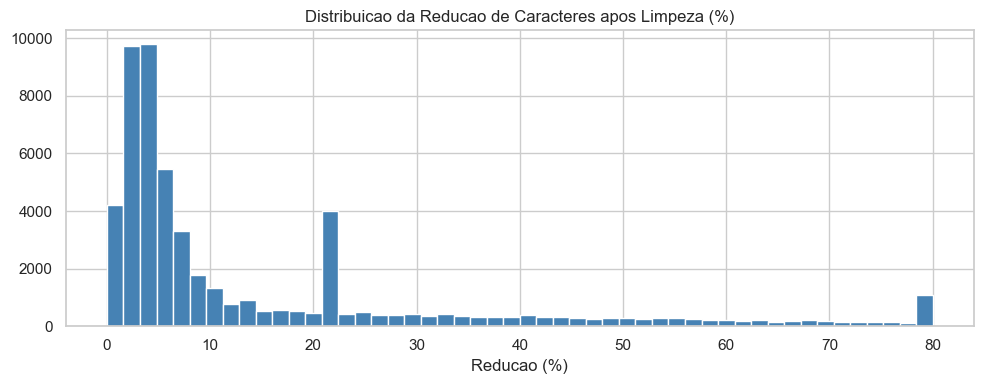

In [3]:
texts_raw = df['body'].fillna('')
texts_clean = texts_raw.apply(clean_text)

# Linhas vazias apos limpeza
mask_empty = texts_clean.str.len() == 0

print(f'Total original    : {len(df):,}')
print(f'Textos vazios pos-limpeza: {mask_empty.sum():,} ({mask_empty.mean()*100:.1f}%)')
print(f'Restante para uso : {(~mask_empty).sum():,} ({(~mask_empty).mean()*100:.1f}%)')

# Comprimento antes vs depois
len_before = texts_raw[~mask_empty].str.len()
len_after  = texts_clean[~mask_empty].str.len()
reducao = ((len_before - len_after) / len_before * 100)

print(f'\nReducao media de caracteres por texto: {reducao.mean():.1f}%')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(reducao.clip(0, 80), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribuicao da Reducao de Caracteres apos Limpeza (%)')
ax.set_xlabel('Reducao (%)')
plt.tight_layout()
plt.show()

3. Analise do vocabulario

Vocabulario total (amostra): 20,322 palavras unicas


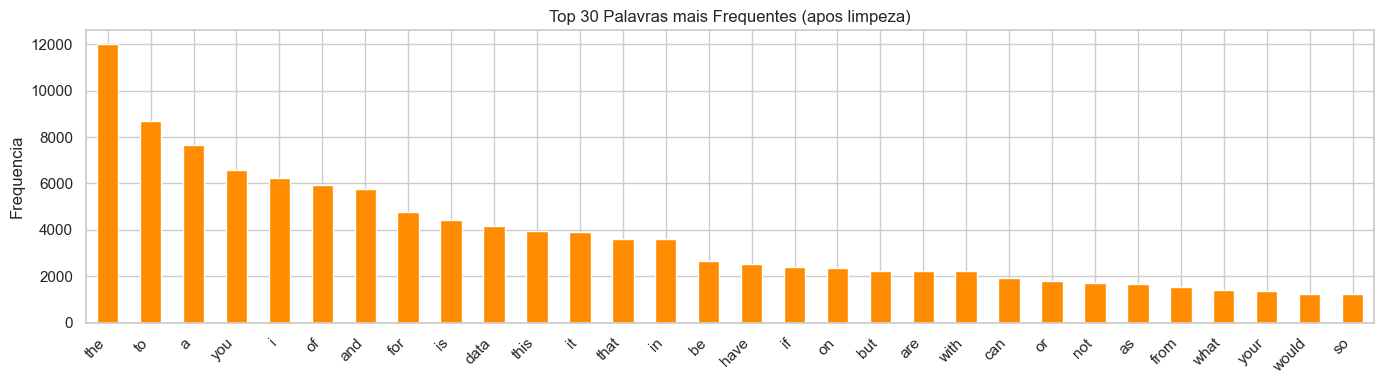


Palavras que aparecem apenas 1 vez: 11,305 (55.6% do vocabulario)


In [4]:
texts_valid = texts_clean[~mask_empty]

# Frequencia de palavras
all_words = ' '.join(texts_valid.sample(min(10000, len(texts_valid)), random_state=42)).split()
word_freq = Counter(all_words)

print(f'Vocabulario total (amostra): {len(word_freq):,} palavras unicas')

# Top 30 palavras
top30 = pd.Series(dict(word_freq.most_common(30)))

plt.figure(figsize=(14, 4))
top30.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Top 30 Palavras mais Frequentes (apos limpeza)')
plt.ylabel('Frequencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Palavras raras (aparecem 1 vez)
rare = sum(1 for v in word_freq.values() if v == 1)
print(f'\nPalavras que aparecem apenas 1 vez: {rare:,} ({rare/len(word_freq)*100:.1f}% do vocabulario)')

4. Experimento: impacto do max_features

max_features=   500 | vocab=   500 | densidade=0.0137
max_features=  1000 | vocab= 1,000 | densidade=0.0085
max_features=  2000 | vocab= 2,000 | densidade=0.0050
max_features=  5000 | vocab= 5,000 | densidade=0.0023
max_features= 10000 | vocab= 5,911 | densidade=0.0020
max_features=  None | vocab= 5,911 | densidade=0.0020


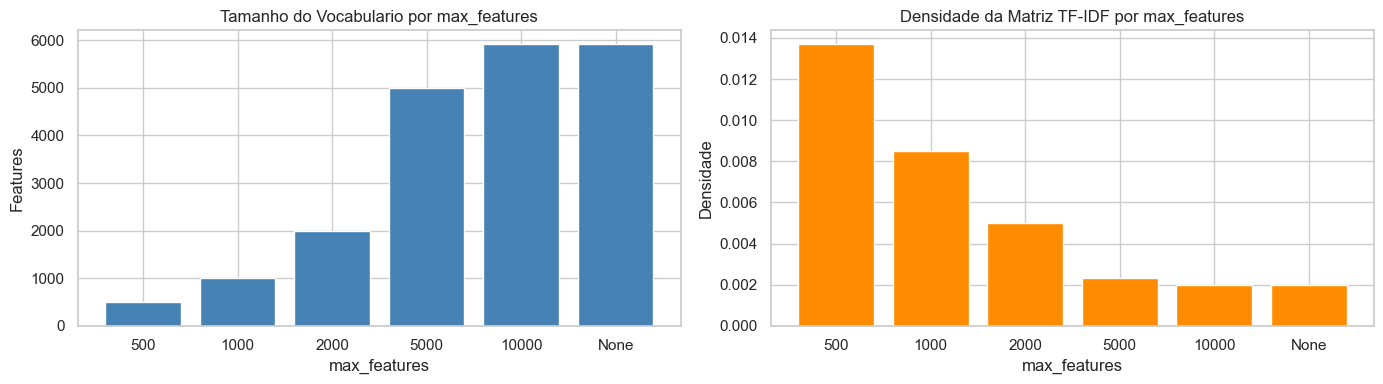

In [5]:
sample_texts = texts_valid.sample(min(20000, len(texts_valid)), random_state=42)

max_features_vals = [500, 1000, 2000, 5000, 10000, None]
results = []

for mf in max_features_vals:
    vec = TfidfVectorizer(max_features=mf, max_df=0.8, min_df=5, stop_words='english')
    X = vec.fit_transform(sample_texts)
    vocab_size = X.shape[1]
    density = X.nnz / (X.shape[0] * X.shape[1])
    results.append({'max_features': str(mf), 'vocab': vocab_size, 'density': density})
    print(f'max_features={str(mf):>6} | vocab={vocab_size:>6,} | densidade={density:.4f}')

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(results_df['max_features'], results_df['vocab'], color='steelblue')
axes[0].set_title('Tamanho do Vocabulario por max_features')
axes[0].set_xlabel('max_features')
axes[0].set_ylabel('Features')

axes[1].bar(results_df['max_features'], results_df['density'], color='darkorange')
axes[1].set_title('Densidade da Matriz TF-IDF por max_features')
axes[1].set_xlabel('max_features')
axes[1].set_ylabel('Densidade')

plt.tight_layout()
plt.show()

5. Experimento: impacto do min_df

min_df=  1 | vocab= 5,000
min_df=  2 | vocab= 5,000
min_df=  5 | vocab= 5,000
min_df= 10 | vocab= 3,598
min_df= 20 | vocab= 2,065
min_df= 50 | vocab=   938


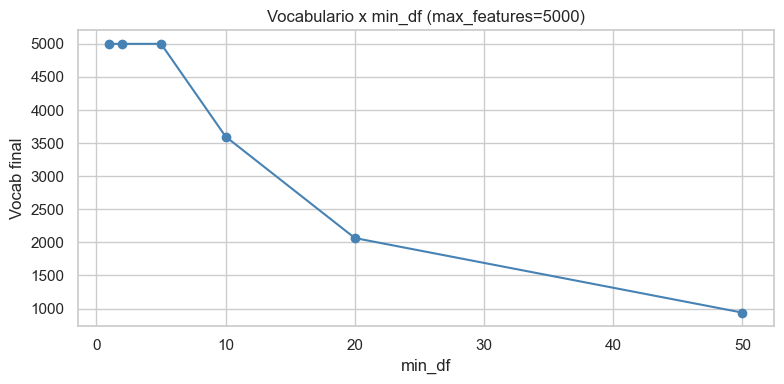


Observacao: min_df=5 elimina palavras raras sem perder muito vocabulario util.


In [6]:
min_df_vals = [1, 2, 5, 10, 20, 50]
results_mindf = []

for md in min_df_vals:
    vec = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=md, stop_words='english')
    X = vec.fit_transform(sample_texts)
    results_mindf.append({'min_df': md, 'vocab': X.shape[1]})
    print(f'min_df={md:>3} | vocab={X.shape[1]:>6,}')

results_mindf_df = pd.DataFrame(results_mindf)

plt.figure(figsize=(8, 4))
plt.plot(results_mindf_df['min_df'], results_mindf_df['vocab'], marker='o', color='steelblue')
plt.title('Vocabulario x min_df (max_features=5000)')
plt.xlabel('min_df')
plt.ylabel('Vocab final')
plt.tight_layout()
plt.show()

print('\nObservacao: min_df=5 elimina palavras raras sem perder muito vocabulario util.')

6. Experimento: impacto do max_df

max_df=0.5 | vocab= 5,000
max_df=0.6 | vocab= 5,000
max_df=0.7 | vocab= 5,000
max_df=0.8 | vocab= 5,000
max_df=0.9 | vocab= 5,000
max_df=1.0 | vocab= 5,000


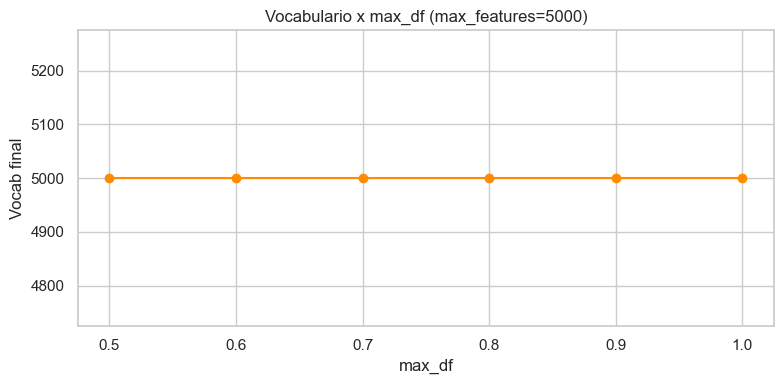

In [7]:
max_df_vals = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results_maxdf = []

for md in max_df_vals:
    vec = TfidfVectorizer(max_features=5000, max_df=md, min_df=5, stop_words='english')
    X = vec.fit_transform(sample_texts)
    results_maxdf.append({'max_df': md, 'vocab': X.shape[1]})
    print(f'max_df={md} | vocab={X.shape[1]:>6,}')

results_maxdf_df = pd.DataFrame(results_maxdf)

plt.figure(figsize=(8, 4))
plt.plot(results_maxdf_df['max_df'], results_maxdf_df['vocab'], marker='o', color='darkorange')
plt.title('Vocabulario x max_df (max_features=5000)')
plt.xlabel('max_df')
plt.ylabel('Vocab final')
plt.tight_layout()
plt.show()

7. Top features TF-IDF com parametros escolhidos

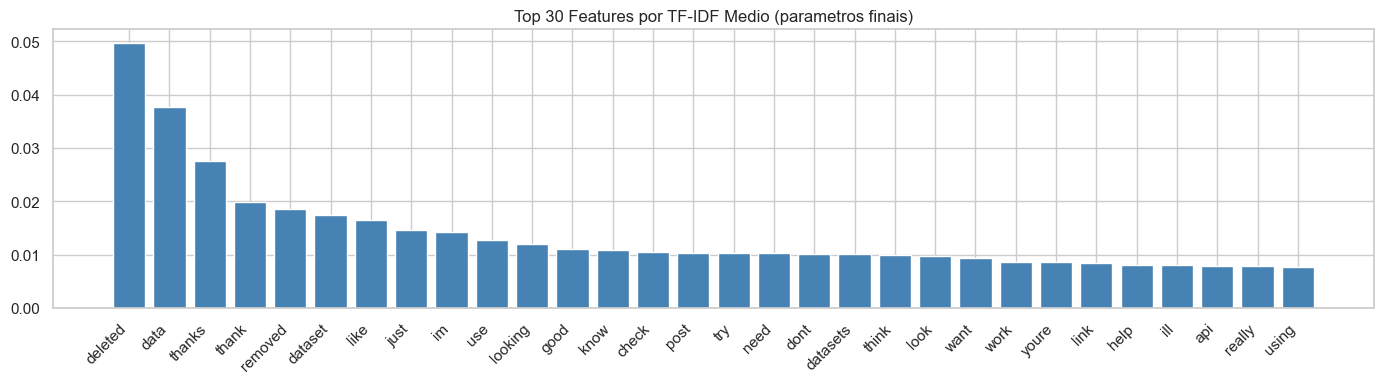


Parametros finais para o pipeline:
  max_features = 5000
  max_df       = 0.8
  min_df       = 5


In [8]:
# Parametros escolhidos para o pipeline
MAX_FEATURES = 5000
MAX_DF = 0.8
MIN_DF = 5

vec_final = TfidfVectorizer(
    max_features=MAX_FEATURES, max_df=MAX_DF, min_df=MIN_DF, stop_words='english'
)
X_final = vec_final.fit_transform(sample_texts)

# Score TF-IDF medio por feature
import numpy as np
mean_tfidf = np.asarray(X_final.mean(axis=0)).flatten()
feature_names = vec_final.get_feature_names_out()
top_idx = mean_tfidf.argsort()[-30:][::-1]

plt.figure(figsize=(14, 4))
plt.bar(feature_names[top_idx], mean_tfidf[top_idx], color='steelblue')
plt.title('Top 30 Features por TF-IDF Medio (parametros finais)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'\nParametros finais para o pipeline:')
print(f'  max_features = {MAX_FEATURES}')
print(f'  max_df       = {MAX_DF}')
print(f'  min_df       = {MIN_DF}')

## 8. Conclusoes

### Limpeza de texto
- **Reducao media de caracteres**: 15.2% por texto — limpeza leve, sem perda excessiva de conteudo
- **Textos removidos pos-limpeza**: 28.1% (21.079 linhas) — a maioria por nulos originais em `body`
- **Linhas uteis apos limpeza**: 54.061 (71.9% do total)
- **Decisao**: limpeza atual e suficiente (lowercase + remove URLs, mentions, especiais)

### Vocabulario
- **Vocabulario total** (amostra 10k textos): 20.322 palavras unicas
- **Palavras hápax** (aparecem apenas 1x): 11.305 (55.6% do vocabulario) → confirma necessidade de `min_df > 1`
- **Vocabulario util maximo** (com min_df=5 + stop_words='english'): **5.911 palavras** — esse e o teto natural do dataset
- **Top palavras brutas**: 'the', 'to', 'a', 'you', 'i' → bem eliminadas pelo `stop_words='english'`

### Experimento max_features
| max_features | vocab final | densidade |
|---|---|---|
| 500 | 500 | 0.01368 |
| 1.000 | 1.000 | 0.00849 |
| 2.000 | 2.000 | 0.00499 |
| **5.000** | **5.000** | **0.00232** |
| 10.000 | 5.911 | 0.00201 |
| None | 5.911 | 0.00201 |

**Conclusao**: max_features=5000 captura 84.6% do vocabulario util (5.000/5.911). Ir alem de 5.000 traz ganho marginal de apenas 911 termos com densidade menor.

### Experimento min_df
| min_df | vocab final |
|---|---|
| 1 | 5.000 (limitado por max_features) |
| 2 | 5.000 (limitado por max_features) |
| **5** | **5.000** |
| 10 | 3.598 (-28%) |
| 20 | 2.065 (-59%) |
| 50 | 938 (-81%) |

**Conclusao**: min_df=5 e o ponto ideal — valores acima causam perda significativa de vocabulario sem beneficio claro.

### Experimento max_df
- Todos os valores testados (0.5 a 1.0) resultaram em vocab=5.000 (sem diferenca)
- **Razao**: `stop_words='english'` ja elimina os termos muito frequentes do ingles; nao ha termos de dominio Reddit suficientemente comuns para ser filtrados pelo max_df neste dataset

### Parametros finais confirmados para o pipeline
```python
MAX_FEATURES = 5000   # captura 84.6% do vocabulario util
MIN_DF       = 5      # elimina hapax sem perda significativa
MAX_DF       = 0.8    # mantido por boas praticas (sem efeito pratico aqui)
stop_words   = 'english'
```

**Proximo passo**: notebook 03 para comparar modelos com esses parametros